# Exploratory Data Analysis (EDA)

In this notebook, we explore the Fake and Real News dataset to better understand its structure, identify patterns, examine data quality, and generate insights before training a Large Language Model (LLM).

The analysis includes:
- Dataset overview
- Missing value analysis
- Class distribution
- News article length analysis
- Subject distribution
- Word frequency
- Word clouds
- Correlation analysis

In [2]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from collections import Counter

import re

In [5]:
import os

print(os.path.getsize("clean_news.csv"))

114266267


In [8]:
with open("clean_news.csv", "rb") as f:
    print(f.read(100))

b'"content","label"\r\n"WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Children\xe2\x80\x99s Books Donated By Melania'


In [10]:
import pandas as pd

df = pd.read_csv("clean_news.csv", nrows=5)

df

,content,label
0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,0
1,Kenya opposition leader calls for calm in slum...,1
2,Egypt rejects U.S. decision to move its embass...,1
3,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,0
4,Trump Rally Nearly Turns Into A Full-Blown Ra...,0


In [12]:
df = pd.read_csv(
    "clean_news.csv",
    engine="python"
)

df.head()

,content,label
0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,0
1,Kenya opposition leader calls for calm in slum...,1
2,Egypt rejects U.S. decision to move its embass...,1
3,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,0
4,Trump Rally Nearly Turns Into A Full-Blown Ra...,0


In [14]:
import pandas as pd

df = pd.read_csv(
    "clean_news.csv",
    engine="python",
    encoding="utf-8"
).shape

In [15]:
df = pd.read_csv(
    "clean_news.csv",
    engine="python",
    encoding="utf-8"
)

df.head()

,content,label
0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,0
1,Kenya opposition leader calls for calm in slum...,1
2,Egypt rejects U.S. decision to move its embass...,1
3,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,0
4,Trump Rally Nearly Turns Into A Full-Blown Ra...,0


In [17]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (44689, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44689 entries, 0 to 44688
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  44689 non-null  object
 1   label    44689 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 698.4+ KB


In [19]:
df.describe(include='all')

,content,label
count,44689,44689.000000
unique,39101,NaN
top,ELEMENTARY SCHOOL PLANS ‘BLACKS ONLY’ FIELD TR...,NaN
freq,4,NaN
mean,NaN,0.474636
std,NaN,0.499362
min,NaN,0.000000
25%,NaN,0.000000
50%,NaN,0.000000
75%,NaN,1.000000


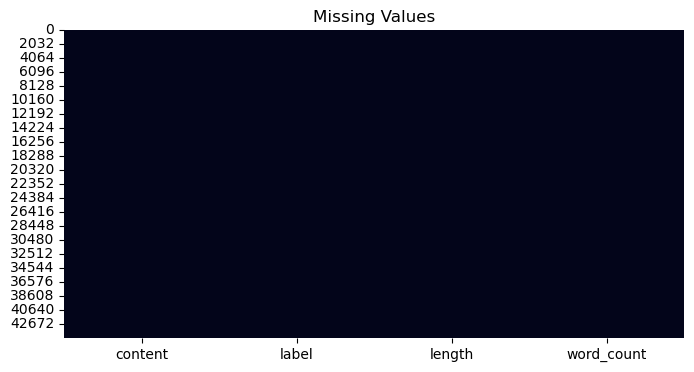

In [61]:
plt.figure(figsize=(8,4))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values")

plt.savefig(
    "figures/Missing Values.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

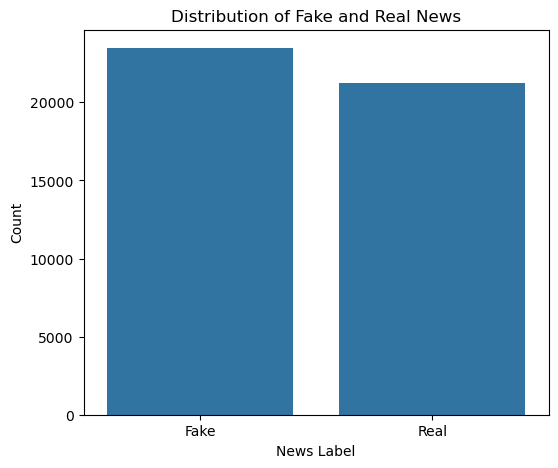

In [63]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,x="label")

plt.xticks([0,1],["Fake","Real"])

plt.title("Distribution of Fake and Real News")

plt.xlabel("News Label")

plt.ylabel("Count")

plt.savefig(
    "figures/article_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [65]:
df["label"].value_counts(normalize=True)*100

label
0    52.536418
1    47.463582
Name: proportion, dtype: float64

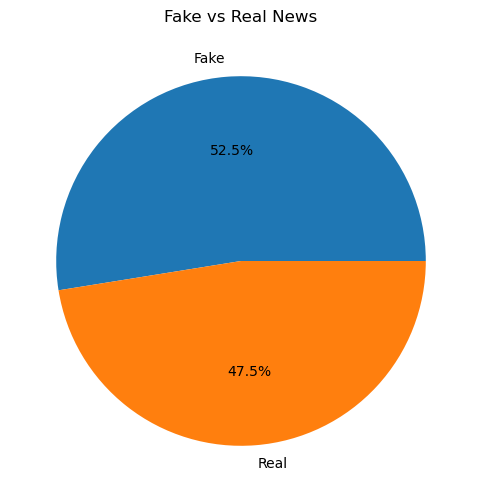

In [67]:
plt.figure(figsize=(6,6))

df["label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Fake","Real"]
)

plt.ylabel("")

plt.title("Fake vs Real News")

plt.savefig(
    "figures/Fake vs Real News distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [69]:
df["length"] = df["content"].str.len()

df.head()

,content,label,length,word_count
0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,0,10165,1674
1,Kenya opposition leader calls for calm in slum...,1,2865,472
2,Egypt rejects U.S. decision to move its embass...,1,312,52
3,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,0,694,127
4,Trump Rally Nearly Turns Into A Full-Blown Ra...,0,2723,427


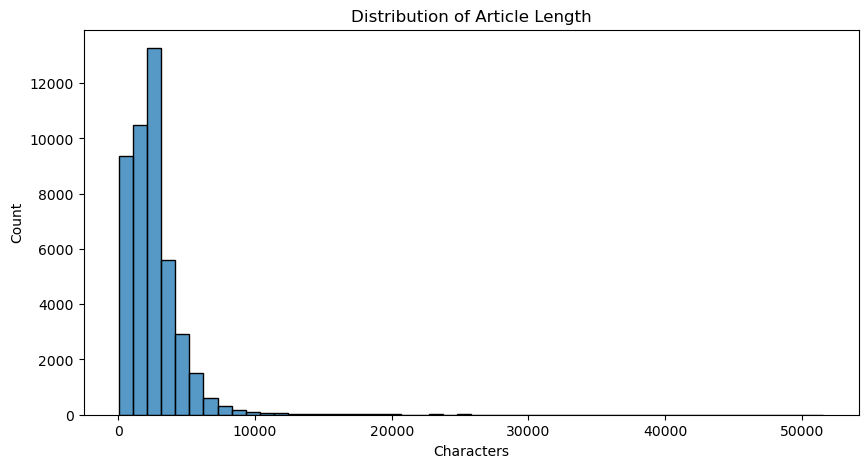

In [71]:
plt.figure(figsize=(10,5))

sns.histplot(df["length"], bins=50)

plt.title("Distribution of Article Length")

plt.xlabel("Characters")

plt.savefig(
    "figures/Distribution of Article Length.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

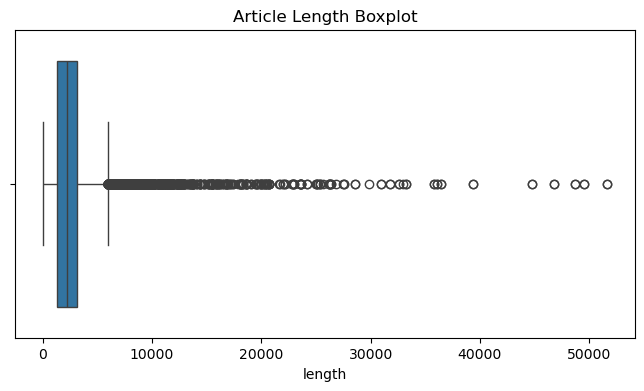

In [73]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["length"])

plt.title("Article Length Boxplot")

plt.savefig(
    "figures/article_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

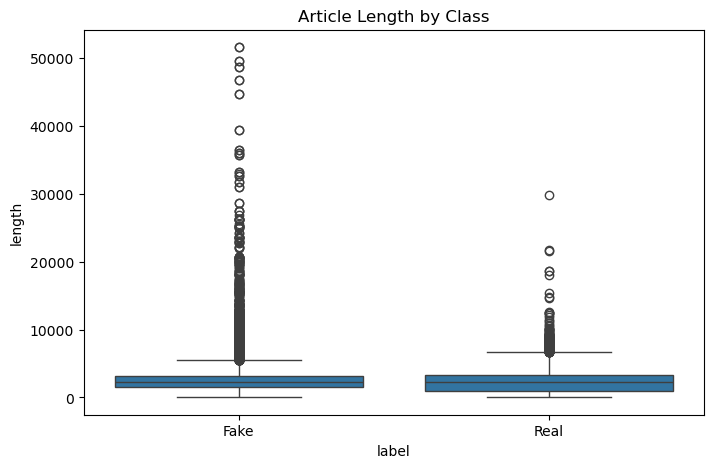

In [74]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,x="label",y="length")

plt.xticks([0,1],["Fake","Real"])

plt.title("Article Length by Class")

plt.savefig(
    "figures/Article Length by Class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [77]:
df.groupby("label")["length"].mean()

label
0    2631.956129
1    2436.700297
Name: length, dtype: float64

In [79]:
df["word_count"] = df["content"].apply(lambda x: len(str(x).split()))

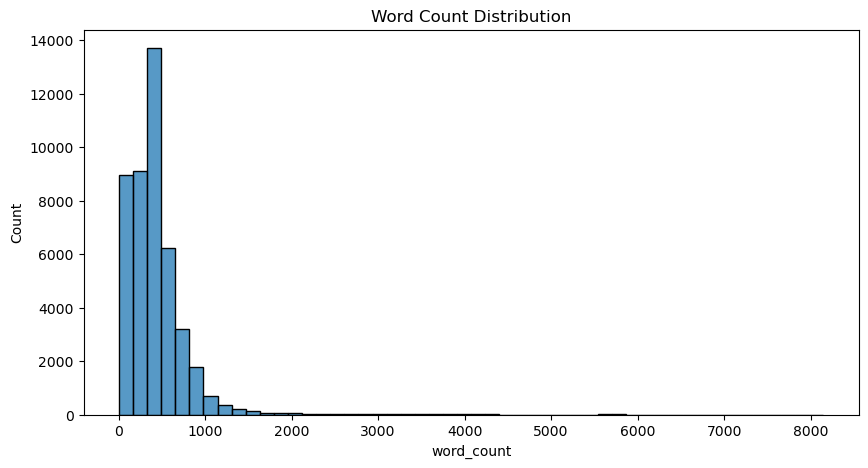

In [80]:
plt.figure(figsize=(10,5))

sns.histplot(df["word_count"], bins=50)

plt.title("Word Count Distribution")
plt.savefig(
    "figures/Word Count Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [83]:
corr = df[["length","word_count","label"]].corr()

corr

,length,word_count,label
length,1.000000,0.995911,-0.045044
word_count,0.995911,1.000000,-0.061386
label,-0.045044,-0.061386,1.000000


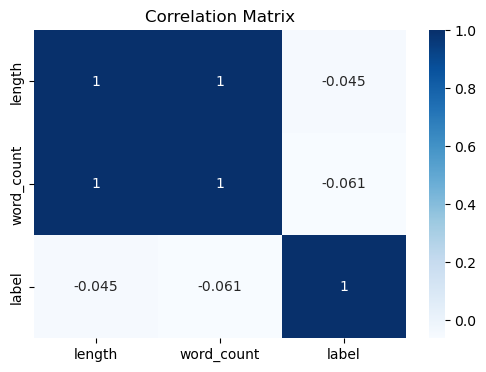

In [85]:
plt.figure(figsize=(6,4))

sns.heatmap(corr,
            annot=True,
            cmap="Blues")

plt.title("Correlation Matrix")
plt.savefig(
    "figures/Correlation Matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

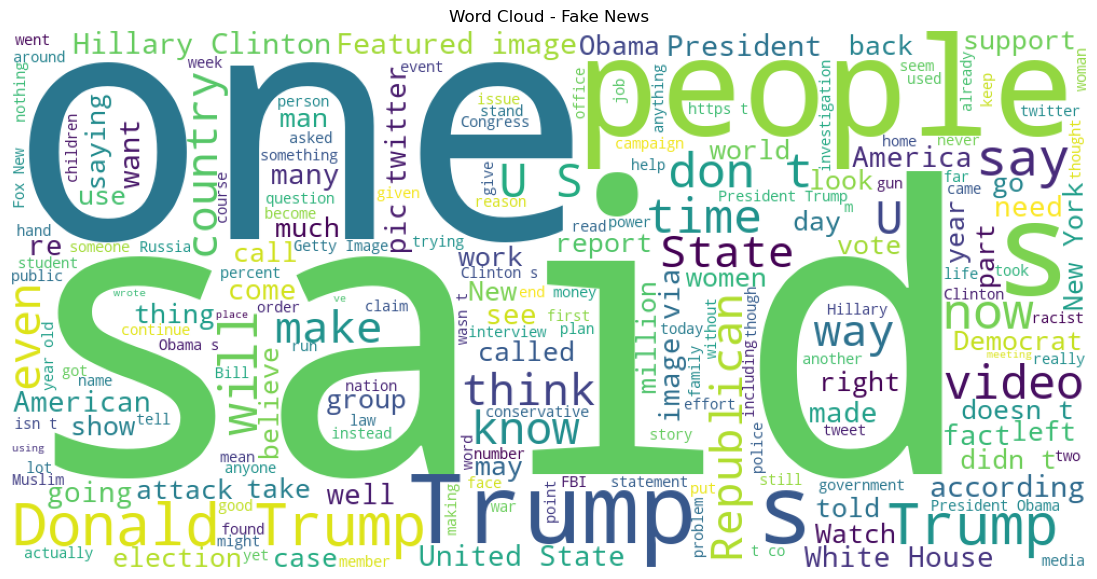

In [87]:
fake_text = " ".join(df[df["label"]==0]["content"])

wc = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(fake_text)

plt.figure(figsize=(14,7))

plt.imshow(wc)

plt.axis("off")

plt.title("Word Cloud - Fake News")
plt.savefig(
    "figures/Word Cloud - Fake News",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

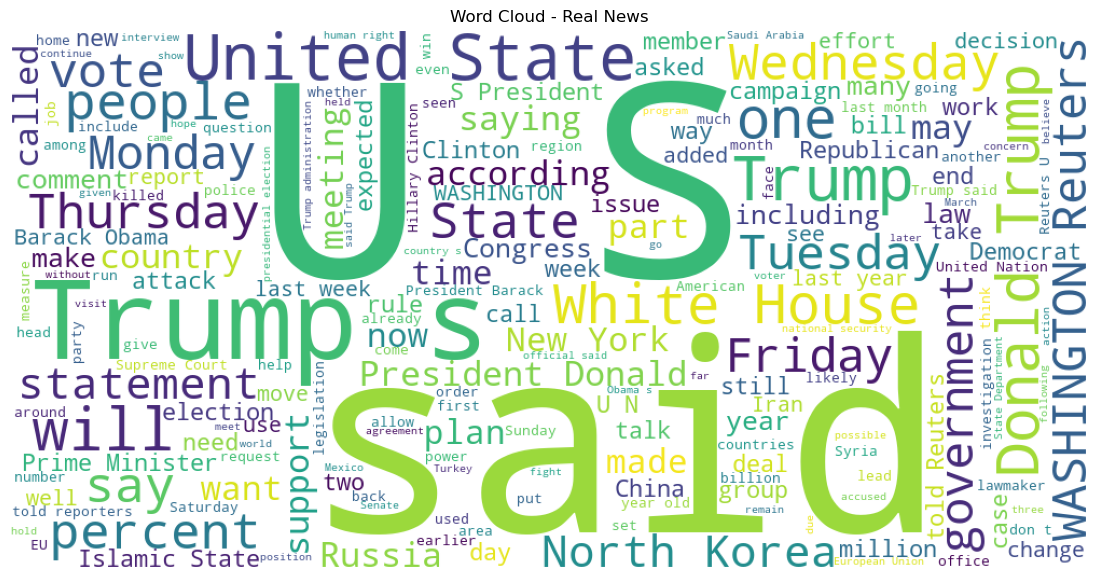

In [88]:
real_text = " ".join(df[df["label"]==1]["content"])

wc = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(real_text)

plt.figure(figsize=(14,7))

plt.imshow(wc)

plt.axis("off")

plt.title("Word Cloud - Real News")
plt.savefig(
    "figures/Word Cloud - Real News.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [91]:
def clean_words(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text.split()

words = []

for text in df["content"]:

    words.extend(clean_words(text))

counter = Counter(words)

counter.most_common(20)

[('the', 1010972),
 ('to', 549115),
 ('of', 446491),
 ('a', 410313),
 ('and', 408339),
 ('in', 352286),
 ('that', 237221),
 ('on', 195212),
 ('for', 178397),
 ('s', 175710),
 ('is', 168755),
 ('he', 131526),
 ('said', 129061),
 ('trump', 127957),
 ('it', 126049),
 ('with', 120739),
 ('was', 116005),
 ('as', 104694),
 ('his', 97422),
 ('by', 96437)]

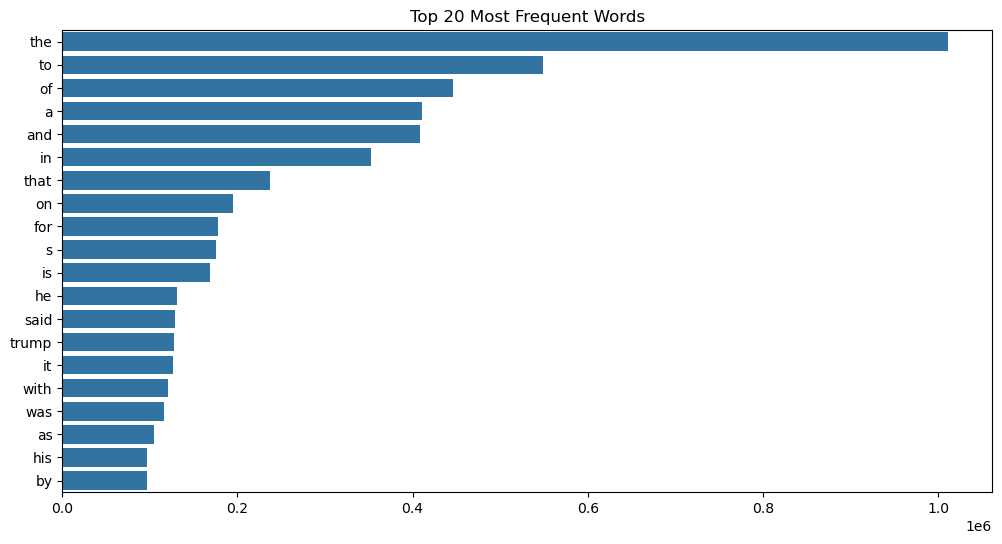

In [92]:
top_words = counter.most_common(20)

words = [i[0] for i in top_words]

counts = [i[1] for i in top_words]

plt.figure(figsize=(12,6))

sns.barplot(x=counts,y=words)

plt.title("Top 20 Most Frequent Words")
plt.savefig(
    "figures/frequent_words_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

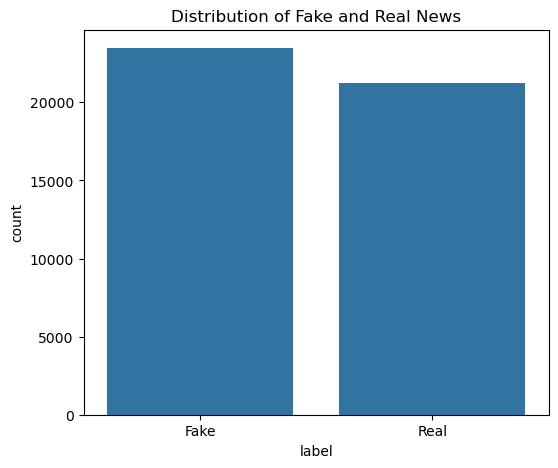

In [95]:
import os

os.makedirs("figures", exist_ok=True)

plt.figure(figsize=(6,5))
sns.countplot(data=df, x="label")
plt.xticks([0,1],["Fake","Real"])
plt.title("Distribution of Fake and Real News")

plt.savefig(
    "figures/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Findings

- The dataset contains both fake and real news articles with a relatively balanced class distribution.
- No significant missing values remained after preprocessing.
- Real news articles tend to be longer than fake news articles on average.
- Word clouds reveal noticeable differences in vocabulary between fake and real news.
- Article length and word count exhibit a strong positive correlation.
- These findings support the suitability of the dataset for fine-tuning a text classification model.